# **Machine Learning Based Model for Human Heart Disease Prediction**

A ML model that utilises the publicly available heart disease dataset(Cleveland UHC dataset) to predict heart disease.
The model is built by the following steps;

## **a) Importing the Libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model  import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score,precision_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split


## **b) Import the dataset**

In [ ]:
dataset = pd.read_csv("/content/heart.csv")

### **i) Dataset Preview**

In [ ]:
print("Dataset first five columns\n",dataset.head())

Dataset first five columns
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [ ]:
print("Summary of the dataset statistics\n", dataset.describe())

Summary of the dataset statistics
               age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean     0.528053  149.646865    0.326733    1.039604    1.399340    0.72

In [ ]:
print("Dataset number of columns and rows",dataset.shape)

Dataset number of columns and rows (303, 14)


In [ ]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


In [ ]:
print(dataset.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


## **c) Exploratory Data Analysis**

The following steps are conducted here to be able to understand the data and guide the preprocessing steps:


1.   Target variable analysis
2.   Univariate variable analysis
3.   Bivariate variable analysis



### **i) Target Variable Analysis**

The dataset's target is studied and inferences are made here.

In [ ]:
dataset['target'].dtype

dtype('int64')

In [ ]:
dataset["target"].isnull().sum()

np.int64(0)

In [ ]:
print(dataset['target'].value_counts())

target
1    165
0    138
Name: count, dtype: int64


/tmp/ipykernel_1735/1737108942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data = dataset, x = 'target', palette = 'viridis')


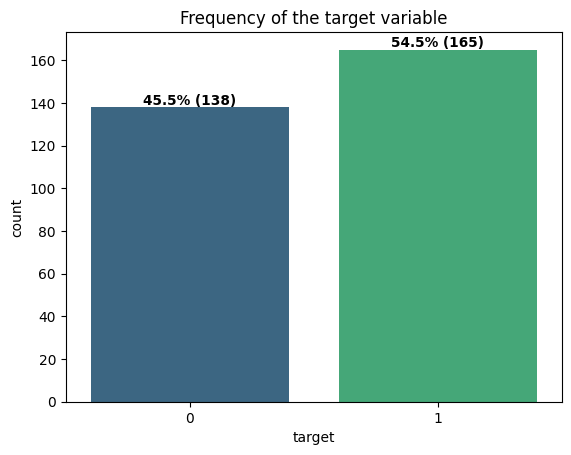

In [ ]:
counts = dataset['target'].value_counts(normalize = True, ascending = True) * 100
count = dataset['target'].value_counts(ascending = True)
ax = sns.countplot(data = dataset, x = 'target', palette = 'viridis')
for i,p in enumerate(ax.patches):
    perc = f"{counts.iloc[i]:.1f}% ({count.iloc[i]})"
    ax.annotate(
        perc,
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha = 'center', va = 'bottom',
        fontsize = 9.8, fontweight = 'bold',
    )
plt.title("Frequency of the target variable")
plt.show()

### **ii) Univariate Analysis**
Decsription statistics for the input features;



In [ ]:
for feature in dataset.columns:
    print(f"Feature statistics for {feature.title()}:\n{dataset[feature].describe()}\n")

Feature statistics for Age:
count    303.000000
mean      54.366337
std        9.082101
min       29.000000
25%       47.500000
50%       55.000000
75%       61.000000
max       77.000000
Name: age, dtype: float64

Feature statistics for Sex:
count    303.000000
mean       0.683168
std        0.466011
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: sex, dtype: float64

Feature statistics for Cp:
count    303.000000
mean       0.966997
std        1.032052
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max        3.000000
Name: cp, dtype: float64

Feature statistics for Trestbps:
count    303.000000
mean     131.623762
std       17.538143
min       94.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

Feature statistics for Chol:
count    303.000000
mean     246.264026
std       51.830751
min      126.000000
25%      211.000000
50%

After individual features have been analysed the input variables are split into two distinct categories for easy EDA
#### **a) Continuous Variables**

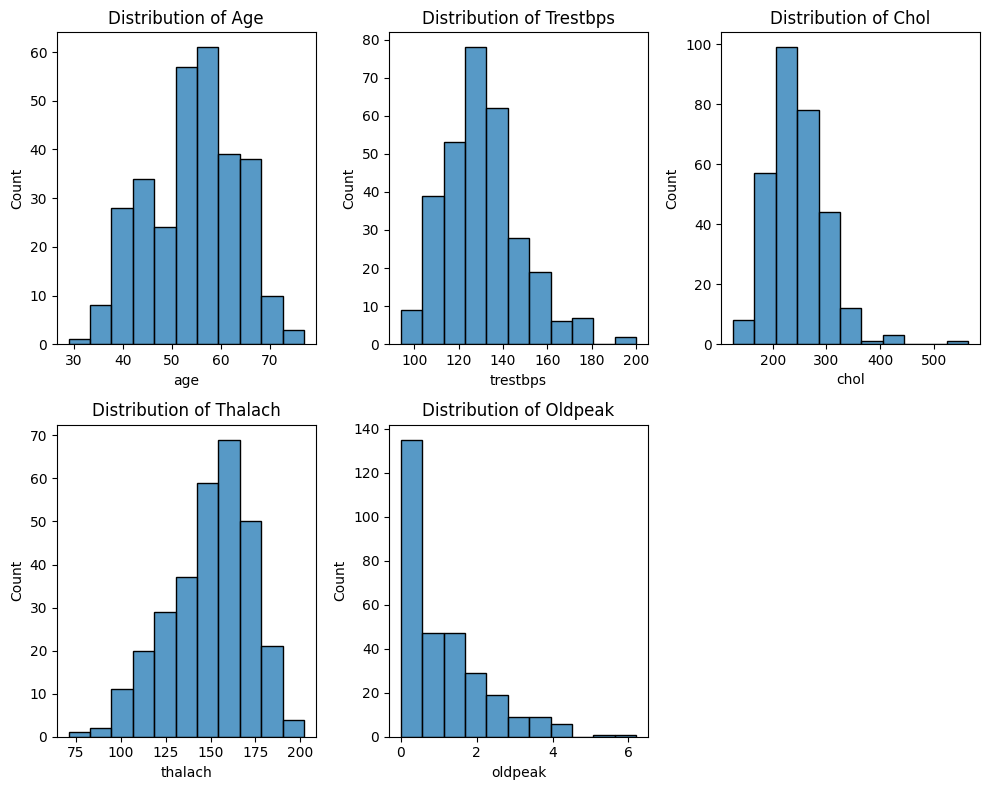

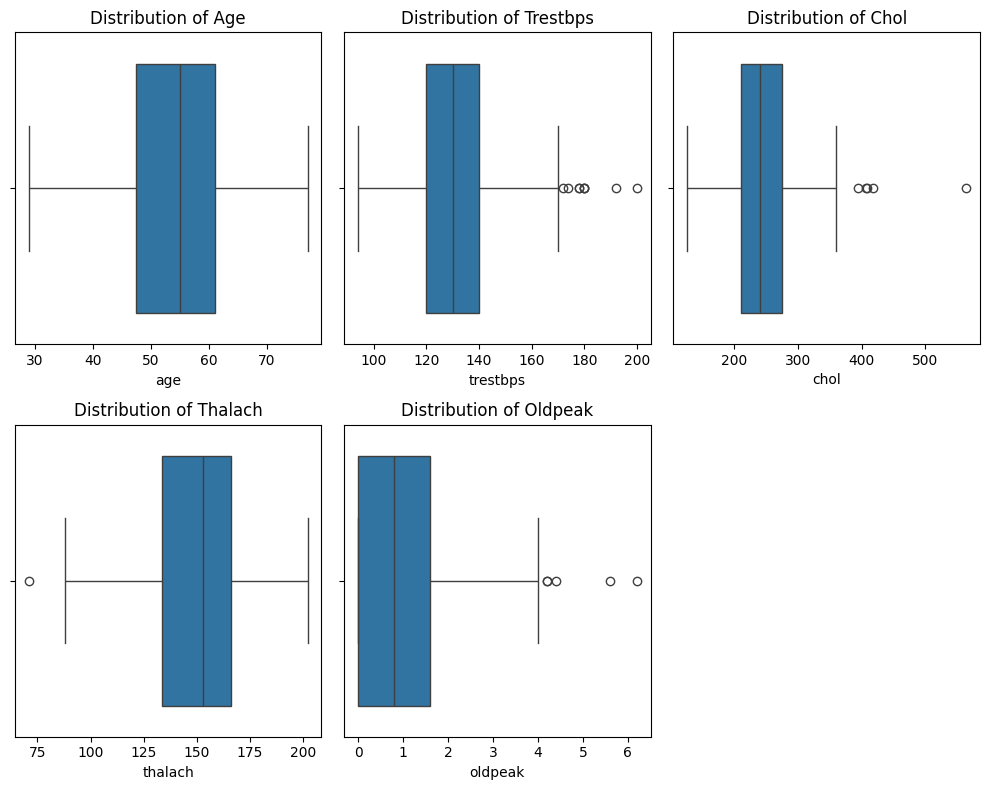

In [ ]:
con_vars = ['age','trestbps','chol','thalach','oldpeak']
cate_vars = [feature for feature in dataset.columns
             if feature not in con_vars + ['target']]
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (10,8))
axes = axes.flatten()

for i,col in enumerate(con_vars):
    ax = axes[i]
    sns.histplot(
        data = dataset,
        bins = 11,
        x = col,
        edgecolor = 'black',
        ax = ax
    )
    ax.set_title(f"Distribution of {col.title()}")
    axes[5].axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (10,8))
axes = axes.flatten()

for i, col in enumerate(con_vars):
    ax = axes[i]
    sns.boxplot(
        data = dataset,
        x = col,
        ax = ax
    )
    ax.set_title(f"Distribution of {col.title()}")
    axes[5].axis('off')

plt.tight_layout()
plt.show()

#### **b)Categorical Variables EDA**

/tmp/ipykernel_1735/2074952489.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = dataset, x = col, palette = 'viridis', ax = ax, order = order)
/tmp/ipykernel_1735/2074952489.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = dataset, x = col, palette = 'viridis', ax = ax, order = order)
/tmp/ipykernel_1735/2074952489.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = dataset, x = col, palette = 'viridis', ax = ax, order = order)
/tmp/ipykernel_1735/2074952489.py:9: FutureWarning: 

Passing `palette` without as

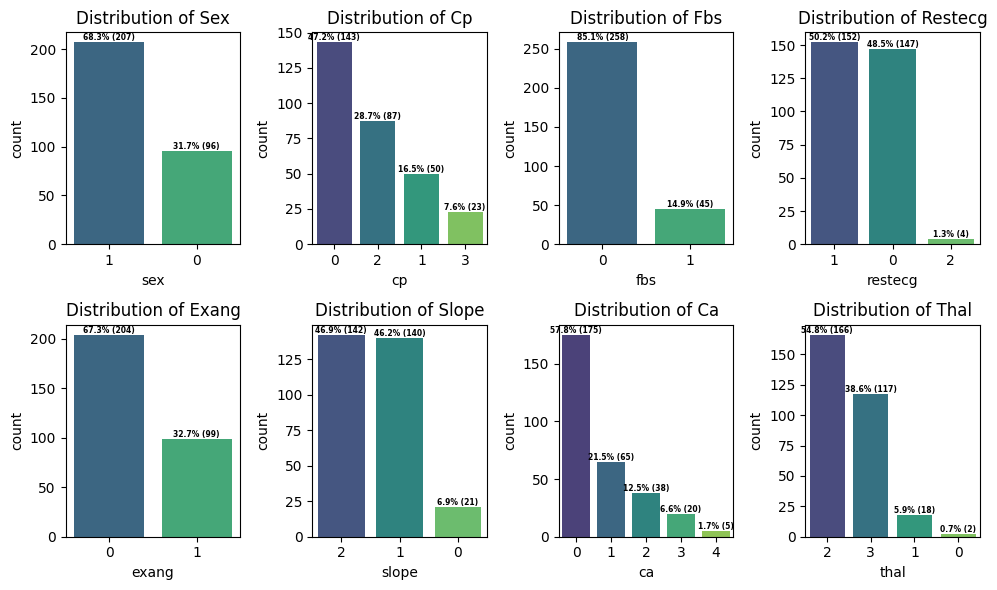

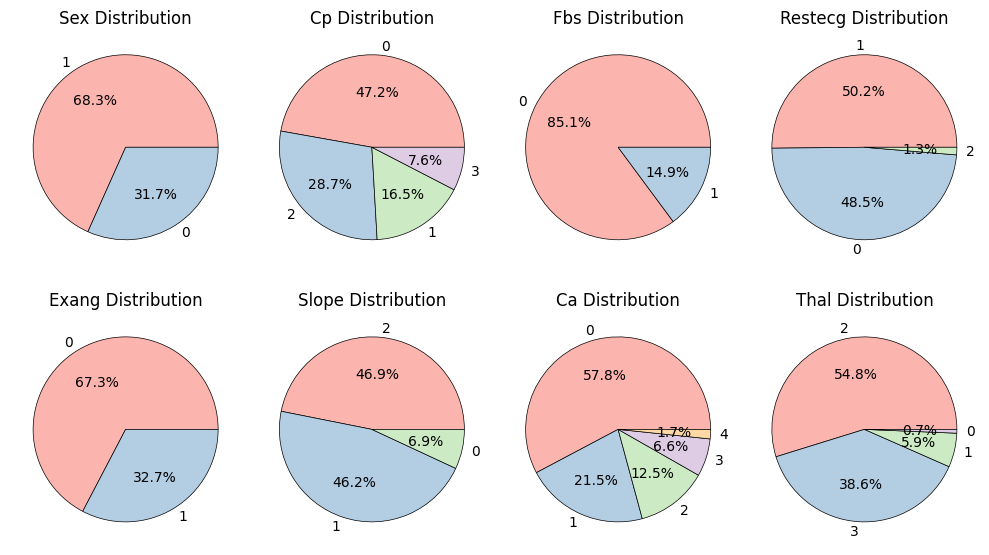

In [ ]:
fig, axes = plt.subplots(nrows = 2, ncols = 4, figsize =(10,6))
axes = axes.flatten()

for i, col in enumerate(cate_vars):
    ax = axes[i]
    counts = dataset[col].value_counts(normalize = True)* 100
    count = dataset[col].value_counts()
    order = counts.index
    sns.countplot(data = dataset, x = col, palette = 'viridis', ax = ax, order = order)

    for j,p in enumerate(ax.patches):
         perc = f"{counts.iloc[j]:.1f}% ({count.iloc[j]})"
         ax.annotate(
             perc,
             (p.get_x() + p.get_width() / 2, p.get_height()),
             ha = 'center', va = 'bottom',
             fontsize = 5.5, fontweight = 'bold'
    )
         ax.set_title(f"Distribution of {col.title()}")

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(ncols = 4, nrows = 2, figsize = (10,6))
axes = axes.flatten()

for i, col in enumerate(cate_vars):

    ax = axes[i]

    counts = dataset[col].value_counts()

    ax.pie(
        counts,
        labels = counts.index,
        colors = plt.cm.Pastel1.colors,
        autopct = '%1.1f%%',
        wedgeprops = {'edgecolor': 'black', 'linewidth': 0.5}
    )

    ax.set_title(f"{col.title()} Distribution")

plt.tight_layout()
plt.show()

### **iii) Multivariate Analysis EDA**

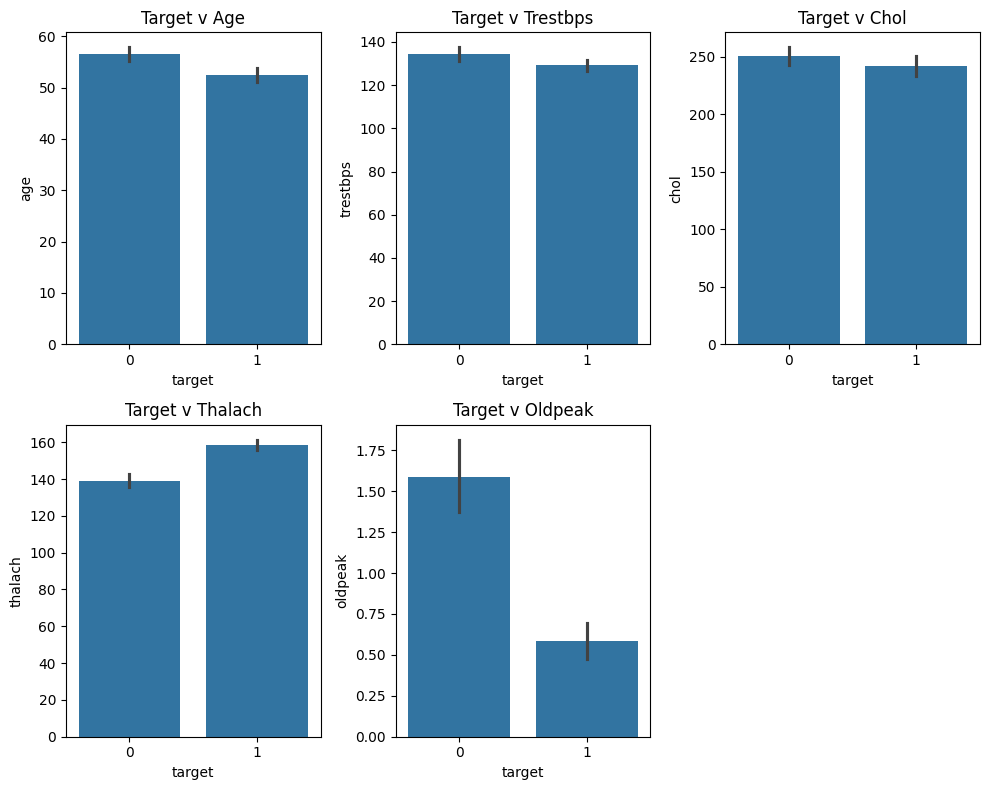

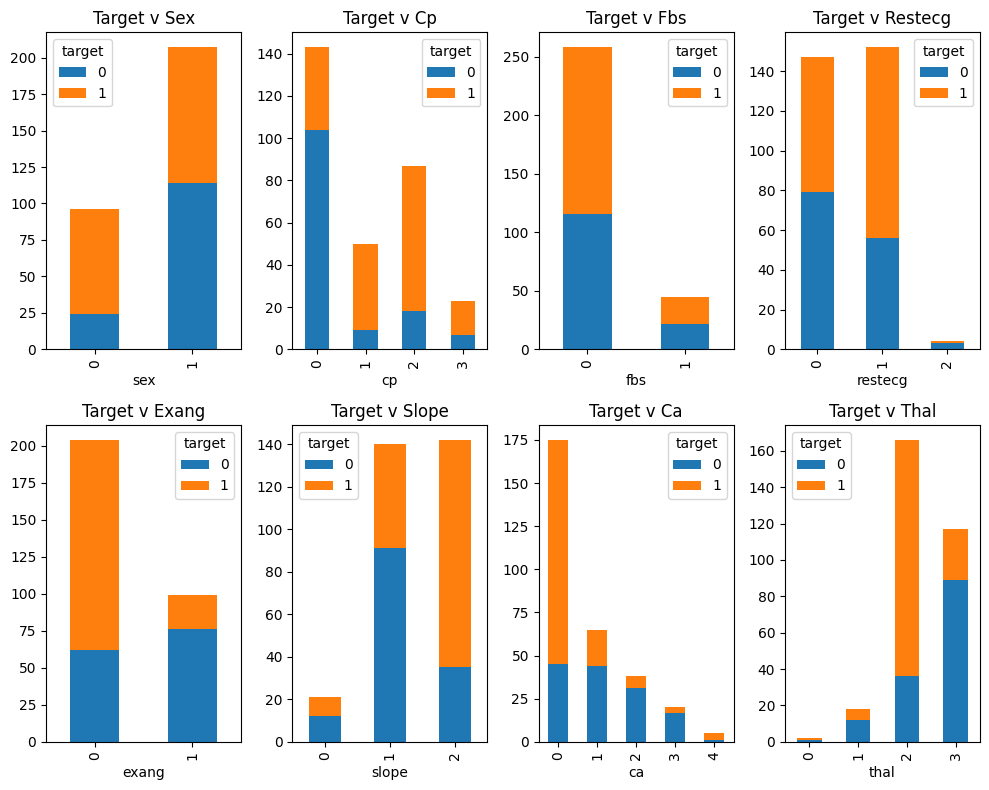

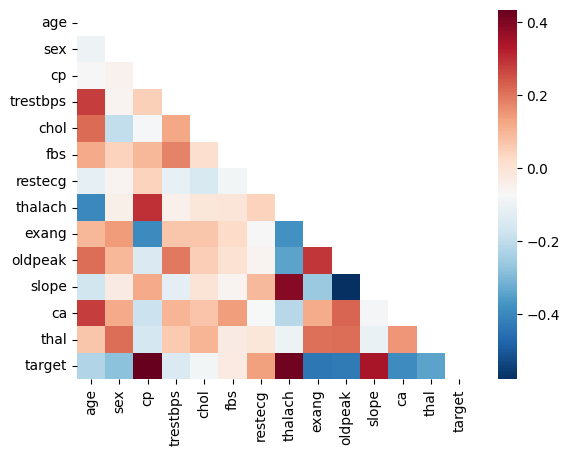

In [ ]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (10,8))
axes = axes.flatten()

for i, col in enumerate(con_vars):
    ax = axes[i]

    sns.barplot(
        data = dataset,
        y = col,
        x = 'target',
        ax = ax
    )
    ax.set_title(f"Target v {col.title()}")
    axes[5].axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows = 2, ncols = 4, figsize = (10,8))
axes = axes.flatten()

for i, col in enumerate(cate_vars):
    ax = axes[i]
    ct = pd.crosstab(dataset[col],dataset['target'])

    ct.plot(kind = 'bar', stacked = True, ax = ax)
    ax.set_title(f"Target v {col.title()}")

plt.tight_layout()
plt.show()

corr = dataset.corr(numeric_only = True)

mask = np.triu(np.ones_like(corr, dtype = bool))

sns.heatmap(corr, mask = mask, cmap = "RdBu_r")
plt.show()



## **d) Data Splitting**
The target is isolated from the input features for data encoding and model training

In [ ]:
x = dataset.drop("target", axis = 1)
y = dataset['target']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

## **e) Data Encoding**
Features with no inherent order are encoded using one hot encoder to avoid the model generating a false order.

In [ ]:
need_encoding = [2,6,12] # Input features in columns 2(cp), columns 6(restecg), columns 12(thal)

preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(drop = 'first'), need_encoding)
    ],
    remainder = 'passthrough'
)

pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  [2, 6, 12])]))])

## **f) Model Training and Evaluation**
The model is trained using appropriate techniques provided by sci-kit

####**i)Random Forest Classifier**

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state = 42)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)
cm = confusion_matrix(y_test,rf_pred)
cm_table = pd.DataFrame(data = cm, columns = ['Predicted Negative(0)', 'Predicted Positive(1)'], index = ['Actual Negative(0)', 'Actual Positive(1)'])
print(cm_table)
print(f"\nRandom Forest accuracy: {accuracy_score(y_test,rf_pred)*100:.2f}%\nRecall: {recall_score(y_test, rf_pred)*100:.2f}%")
print(f"\nPrecision : {precision_score(y_test,rf_pred)*100:.2f}%\nF1_score: {f1_score(y_test, rf_pred)*100:.2f}%")


                    Predicted Negative(0)  Predicted Positive(1)
Actual Negative(0)                     19                      9
Actual Positive(1)                      1                     32

Random Forest accuracy: 83.61%
Recall: 96.97%

Precision : 78.05%
F1_score: 86.49%


####**ii)Decision Tree Classifier**

In [ ]:
dt = DecisionTreeClassifier(random_state = 42)
dt.fit(x_train,y_train)
dt_pred = dt.predict(x_test)
cm = confusion_matrix(y_test,dt_pred)
cm_table = pd.DataFrame(data = cm, columns = ['Predicted Negative(0)', 'Predicted Positive(1)'], index = ['Actual Negative(0)', 'Actual Positive(1)'])
print(cm_table)
print(f"\nDecision tree accuracy: {accuracy_score(y_test,dt_pred)*100:.2f}%\nRecall: {recall_score(y_test, dt_pred)*100:.2f}%")
print(f"\nPrecision: {precision_score(y_test,dt_pred)*100:.2f}%\nF1: {f1_score(y_test, dt_pred)*100:.2f}%")

                    Predicted Negative(0)  Predicted Positive(1)
Actual Negative(0)                     17                     11
Actual Positive(1)                      7                     26

Decision tree accuracy: 70.49%
Recall: 78.79%

Precision: 70.27%
F1: 74.29%


####**iii) Support Vector Machine**

In [ ]:
svm_model = SVC(kernel='rbf', random_state=42)
scaler = StandardScaler()
x_train[con_vars] = scaler.fit_transform(x_train[con_vars])
x_test[con_vars] = scaler.transform(x_test[con_vars])
svm_model.fit(x_train, y_train)
svm_pred = svm_model.predict(x_test)
cm = confusion_matrix(y_test,svm_pred)
cm_table = pd.DataFrame(data = cm, columns = ['Predicted Negative(0)', 'Predicted Positive(1)'], index = ['Actual Negative(0)', 'Actual Positive(1)'])
print(cm_table)
print(f"\nSVM Accuracy: {accuracy_score(y_test, svm_pred)*100:.2f}%\nRecall: {recall_score(y_test, svm_pred)*100.:.2f}%")
print(f"\nPrecison: {precision_score(y_test, svm_pred)*100:.2f}%\nF1: {f1_score(y_test, svm_pred)*100.:.2f}%")

                    Predicted Negative(0)  Predicted Positive(1)
Actual Negative(0)                     18                     10
Actual Positive(1)                      2                     31

SVM Accuracy: 80.33%
Recall: 93.94%

Precison: 75.61%
F1: 83.78%


####**iv) Logistic Regression**

In [ ]:
lr_model = LogisticRegression()
lr_model.fit(x_train, y_train)
lr_pred = lr_model.predict(x_test)
cm = confusion_matrix(y_test,lr_pred)
cm_table = pd.DataFrame(data = cm, columns = ['Predicted Negative(0)', 'Predicted Positive(1)'], index = ['Actual Negative(0)', 'Actual Positive(1)'])
print(cm_table)
print(f"\nLogistic Regression accuracy: {accuracy_score(y_test,lr_pred)*100:.2f}%\nRecall: {recall_score(y_test, lr_pred)*100:.2f}%")
print(f"\nPrecision: {precision_score(y_test, lr_pred)*100:.2f}%\nF1: {f1_score(y_test, lr_pred)*100.:.2f}%")

                    Predicted Negative(0)  Predicted Positive(1)
Actual Negative(0)                     19                      9
Actual Positive(1)                      3                     30

Logistic Regression accuracy: 80.33%
Recall: 90.91%

Precision: 76.92%
F1: 83.33%


The random forest classifier is selected due to its high recall which is important during medical setting.